<a href="https://colab.research.google.com/github/itharavenikarthik/Machine-learning/blob/main/2403A52200_ML_Lab_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv('/content/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
df=df[['Survived','Pclass','Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embarked']]
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df.isnull().sum()


/tmp/ipykernel_4202/3822417998.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
df.drop(columns=['Cabin'],inplace=True)

In [ ]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/tmp/ipykernel_4202/3717664479.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [ ]:
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['Ticket']=le.fit_transform(df['Ticket'])
df['Embarked']=le.fit_transform(df['Embarked'])

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,1,22.0,1,0,523,7.2500,2
1,1,1,0,38.0,1,0,596,71.2833,0
2,1,3,0,26.0,0,0,669,7.9250,2
3,1,1,0,35.0,1,0,49,53.1000,2
4,0,3,1,35.0,0,0,472,8.0500,2


In [ ]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
depth_values=[2,4,6,8]
criteria=['gini','entropy']
results=[]
for c in criteria:
  for depth in depth_values:
    model=DecisionTreeClassifier(criterion=c,max_depth=depth,random_state=42)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print('Criteria:',c)
    print('Max Depth:',depth)
    print('Accuracy:',accuracy)
    print('F1 Score:',f1)
    print('Confusion Matrix')
    print(cm)
    results.append([c,depth,accuracy,f1])

Criteria: gini
Max Depth: 2
Accuracy: 0.7723880597014925
F1 Score: 0.6514285714285715
Confusion Matrix
[[150   7]
 [ 54  57]]
Criteria: gini
Max Depth: 4
Accuracy: 0.7873134328358209
F1 Score: 0.7135678391959799
Confusion Matrix
[[140  17]
 [ 40  71]]
Criteria: gini
Max Depth: 6
Accuracy: 0.746268656716418
F1 Score: 0.6822429906542056
Confusion Matrix
[[127  30]
 [ 38  73]]
Criteria: gini
Max Depth: 8
Accuracy: 0.7276119402985075
F1 Score: 0.6572769953051644
Confusion Matrix
[[125  32]
 [ 41  70]]
Criteria: entropy
Max Depth: 2
Accuracy: 0.7723880597014925
F1 Score: 0.6514285714285715
Confusion Matrix
[[150   7]
 [ 54  57]]
Criteria: entropy
Max Depth: 4
Accuracy: 0.8097014925373134
F1 Score: 0.7605633802816901
Confusion Matrix
[[136  21]
 [ 30  81]]
Criteria: entropy
Max Depth: 6
Accuracy: 0.753731343283582
F1 Score: 0.7105263157894737
Confusion Matrix
[[121  36]
 [ 30  81]]
Criteria: entropy
Max Depth: 8
Accuracy: 0.75
F1 Score: 0.6854460093896714
Confusion Matrix
[[128  29]
 [ 38  7

In [ ]:
results_df=pd.DataFrame(results,columns=['Criteria','Max Depth','Accuracy','F1 Score'])
results_df

,Criteria,Max Depth,Accuracy,F1 Score
0,gini,2,0.772388,0.651429
1,gini,4,0.787313,0.713568
2,gini,6,0.746269,0.682243
3,gini,8,0.727612,0.657277
4,entropy,2,0.772388,0.651429
5,entropy,4,0.809701,0.760563
6,entropy,6,0.753731,0.710526
7,entropy,8,0.750000,0.685446


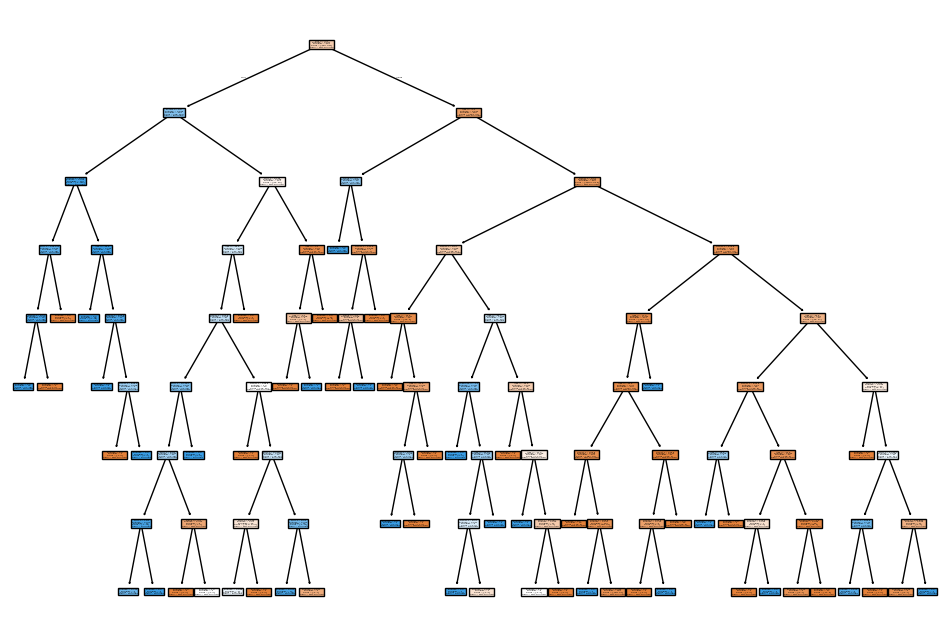

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(model,feature_names=x.columns,class_names=['Not Survived','Survived'],filled=True)
plt.show()